In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.optimize import curve_fit
from joblib import Parallel, delayed

%matplotlib widget

In [2]:
!ptdump /media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_Kr83m/dorothea/NEXT100_Kr83m_dorothea_3256.h5


/ (RootGroup) ''
/DST (Group) ''
/DST/Events (Table(1047,)shuffle, zlib(4)) 'KDST Events'
/Filters (Group) ''
/Filters/s12_selector (Table(997,)shuffle, zlib(4)) 'Event has passed filter flag'
/MC (Group) ''
/MC/configuration (Table(27,)shuffle, zlib(4)) ''
/MC/event_mapping (Table(929,)shuffle, zlib(4)) ''
/MC/hits (Table(25633,)shuffle, zlib(4)) ''
/MC/particles (Table(4552,)shuffle, zlib(4)) ''
/MC/sns_positions (Table(0,)shuffle, zlib(4)) ''
/MC/sns_response (Table(0,)shuffle, zlib(4)) ''
/Run (Group) ''
/Run/eventMap (Table(929,)shuffle, zlib(4)) ''
/Run/events (Table(929,)shuffle, zlib(4)) 'event info table'
/Run/runInfo (Table(929,)shuffle, zlib(4)) 'run info table'
/config (Group) ''
/config/detsim (Table(29,)shuffle, zlib(4)) 'configuration for detsim'
/config/dorothea (Table(32,)shuffle, zlib(4)) 'configuration for dorothea'
/config/hypathia (Table(30,)shuffle, zlib(4)) 'configuration for hypathia'


In [2]:
# Load in the MC true for all events
def process_single_file(f):
    """Worker function for one file"""
    try:
        dst = pd.read_hdf(f, "DST/Events")
        return dst
    except Exception as e:
        print(f"Error in {f}: {e}")
        return None

def LoadFilesParallel(filepath):
    files = glob.glob(filepath)
    
    # n_jobs=-1 uses all available cores (all 60)
    # prefer="threads" is good for I/O, but "processes" is better for pandas filtering
    results = Parallel(n_jobs=-1, verbose=10)( delayed(process_single_file)(f) for f in files)
    
    # Filter out None results if any files failed to load
    results = [res for res in results if res is not None]
    
    return pd.concat(results)


# dsts = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_Kr83m/dorothea/*.h5")
dsts = LoadFilesParallel(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_Kr83m_Pyrrha/dorothea/*.h5")
print("Number of events:", len(dsts.event.unique()))

dsts = dsts[dsts["DT"] > 0]
dsts = dsts[dsts["S2e"] > 3.5e3]
print("Number of events after cuts:", len(dsts.event.unique()))

display(dsts)

print(dsts.columns)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 137 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 185 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    4.6s
[Parallel(n_jobs=-1)]: Done 237 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 293 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 322 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 353 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 384 tasks      | elapsed:    7.2s


KeyboardInterrupt: 

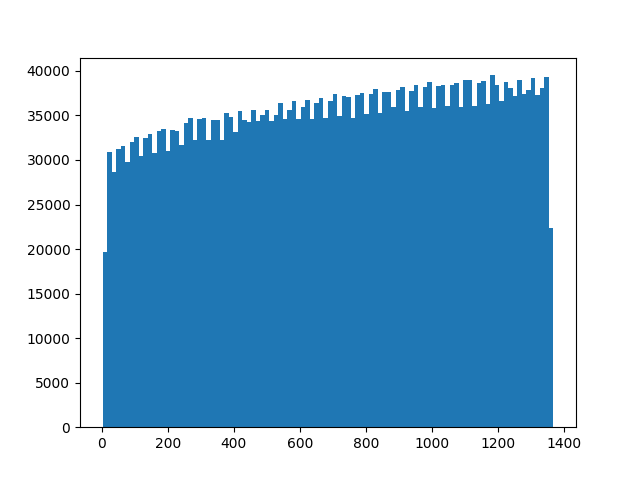

In [8]:
plt.figure()

plt.hist(dsts["DT"], bins = 100);

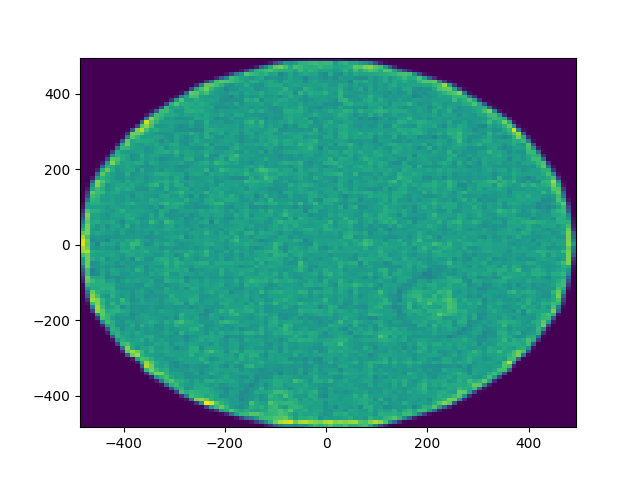

In [9]:
plt.figure()
plt.hist2d(dsts["X"], dsts["Y"], bins = 100);

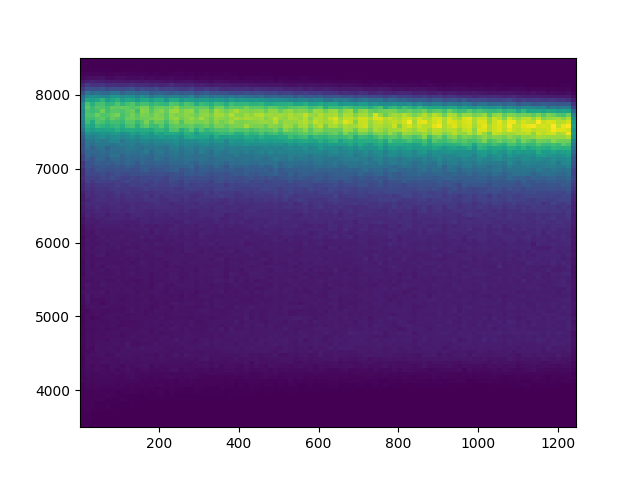

In [10]:
plt.figure()

plt.hist2d(dsts.Z, dsts.S2e, bins = 100);

In [11]:
# Rebin the x and y

nbins = 75

# Define bin edges using np.linspace for x and y
x_bins = np.linspace(-500, 500, nbins)  # 10 evenly spaced bins between -500 and 500
y_bins = np.linspace(-500, 500, nbins)

# Bin the x and y columns
dsts['x_bin'] = pd.cut(dsts['X'], bins=x_bins, labels=False)  # Labels as index (0, 1, 2,...)
dsts['y_bin'] = pd.cut(dsts['Y'], bins=y_bins, labels=False)

# Calculate bin centers
x_bin_centers = (x_bins[:-1] + x_bins[1:]) / 2  # Bin centers for x
y_bin_centers = (y_bins[:-1] + y_bins[1:]) / 2  # Bin centers for y

print(sorted(dsts['x_bin'].unique()))
print(len(dsts['x_bin'].unique()))

# Assign the bin centers as new columns
dsts['x_bin_center'] = dsts['x_bin'].map(lambda i: x_bin_centers[i] if pd.notna(i) else np.nan)
dsts['y_bin_center'] = dsts['y_bin'].map(lambda i: y_bin_centers[i] if pd.notna(i) else np.nan)

# Assign a unique bin ID for each (x_bin, y_bin) pair
dsts['bin_id'] = dsts['x_bin'].astype(str) + '_' + dsts['y_bin'].astype(str)

display(dsts)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73]
73


,event,time,s1_peak,s2_peak,nS1,nS2,S1w,S1h,S1e,S1t,...,Y,R,Phi,Xrms,Yrms,x_bin,y_bin,x_bin_center,y_bin_center,bin_id
0,2968000,5.936000e+12,0,0,1,1,275.0,1.929869,8.019158,10025.0,...,142.570486,146.626739,1.806560,7.994045,8.617671,34,47,-33.783784,141.891892,34_47
1,2968001,5.936003e+12,0,0,1,1,100.0,2.871875,8.414449,10075.0,...,-267.732986,376.707379,-0.790519,13.190977,13.626476,56,17,263.513514,-263.513514,56_17
2,2968002,5.936006e+12,0,0,1,1,150.0,3.642608,12.219065,10100.0,...,-466.557374,474.860679,-1.758077,14.333083,18.692074,30,2,-87.837838,-466.216216,30_2
3,2968003,5.936007e+12,0,0,1,1,100.0,5.516716,9.107391,10000.0,...,391.911971,413.351384,1.247309,15.597255,11.013121,46,66,128.378378,398.648649,46_66
4,2968004,5.936009e+12,0,0,1,1,175.0,3.764114,13.158407,10050.0,...,377.272887,438.601932,2.105987,12.967910,14.110687,20,64,-222.972973,371.621622,20_64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1025,2512995,5.025991e+12,0,0,1,1,325.0,5.805114,18.013899,10000.0,...,-231.217061,477.963714,-0.504939,10.925424,11.604882,67,19,412.162162,-236.486486,67_19
1026,2512996,5.025992e+12,0,0,1,1,175.0,5.131178,14.222141,10000.0,...,257.990267,263.930397,1.783359,13.378416,13.728450,32,56,-60.810811,263.513514,32_56
1027,2512997,5.025995e+12,0,0,1,1,200.0,3.201903,10.411630,10050.0,...,-280.856963,324.139759,-2.093508,14.431317,12.865136,25,16,-155.405405,-277.027027,25_16
1028,2512998,5.025997e+12,0,0,1,2,225.0,1.877958,7.161094,10100.0,...,-301.908230,432.667636,-0.772298,13.531075,14.849101,59,14,304.054054,-304.054054,59_14


7749.53564453125
37_39 7912.9519026328935 65.02337890866943
7763.0140625
37_38 7861.084696487729 79.42945757658761


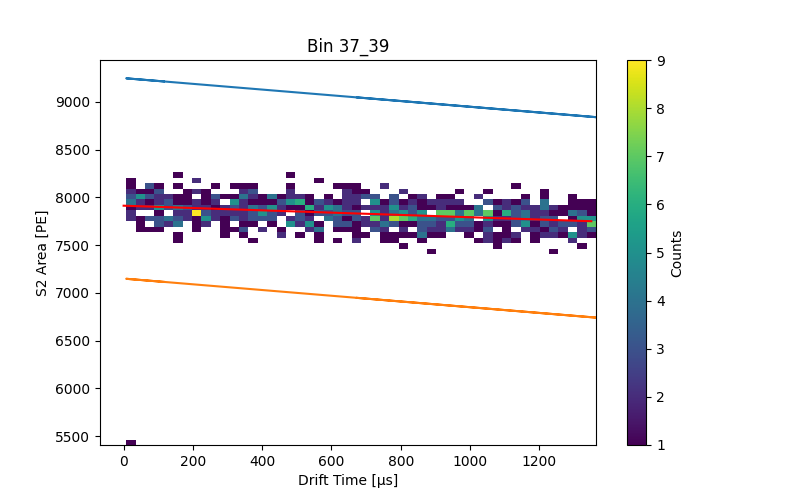

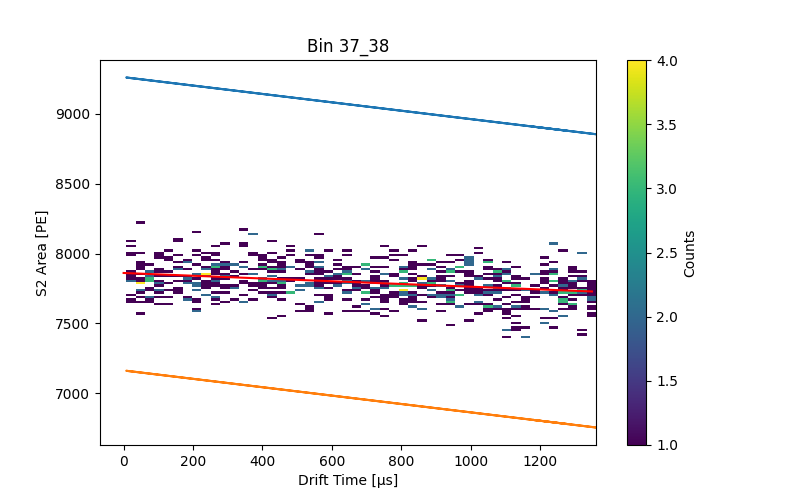

In [12]:
bound_params = 600, 1500, 0.3

# Define the exponential decay function
def exp_decay(t, q, tau):
    if (tau == 0):
        return np.ones(len(t))
    else:
        return q * np.exp(-t / tau)

def FitLifetime(df, binid):

    # Filter data based on the current bin_id
    df_bin = df[df.bin_id == binid] 
    
    # df_bin = df_bin[df_bin.DT >600]

    # Get the histogram with the most counts to find the main alpha peak
    counts, bin_edges = np.histogram(df_bin.S2e, bins=50) 
    max_bin_index = np.argmax(counts)  # Index of the bin with the most counts
    max_bin_value = bin_edges[max_bin_index]  # Left edge of the bin with the most counts
    print(max_bin_value)

    lower_bound = max_bin_value-bound_params[0]
    upper_bound = max_bin_value+bound_params[1]

    # lower_bound = 6e3
    # upper_bound = 7.1e3

    # print("Max bin value is:", max_bin_value)
    # print("Lower/upper bound is:", lower_bound, upper_bound)

    df_bin = df_bin[ (df_bin.S2e > -bound_params[2]*df_bin.DT+lower_bound) & (df_bin.S2e < -bound_params[2]*df_bin.DT+upper_bound)  ]

    if (len(df_bin) < 15):
        return 0, 0

    # Make 2D hist for binning
    hist, x_edges, y_edges = np.histogram2d(df_bin['DT'], df_bin['S2e'], bins=100)

    t = np.linspace(0,1350,300)
    plt.plot(df_bin['DT'], -bound_params[2]*df_bin.DT+upper_bound) # if you want to plot the bands plot this. 
    plt.plot(df_bin['DT'], -bound_params[2]*df_bin.DT+lower_bound)

    # plt.plot(df_bin['deltaT'], -0.3*df_bin.deltaT+7.2e3) # if you want to plot the bands plot this. 
    # plt.plot(df_bin['deltaT'], -0.3*df_bin.deltaT+6.5e3)
    
    # Perform the curve fit
    params, covariance = curve_fit(exp_decay, df_bin.DT, df_bin.S2e, bounds = ([0, 1e3], [5e4, 2000e3]))


    # Extract the fitted parameters
    q_fit, tau_fit = params
    print(binid, q_fit, tau_fit/1e3 )

    return q_fit, tau_fit


def PlotSpecificBin(bin_ = "37_39"):

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    df_bin = dsts[dsts.bin_id == bin_] # 4_5, 
    hist, x_edges, y_edges = np.histogram2d(df_bin['DT'], df_bin['S2e'], bins=50)
    masked_hist = np.ma.masked_where(hist == 0, hist)  # Mask bins where the count is zero
    cmap = plt.cm.viridis
    cmap.set_bad(color='white')  # Set masked values (zeros) to white
    pcm = ax.pcolormesh(x_edges, y_edges, masked_hist.T, cmap=cmap)
    plt.colorbar(pcm, ax=ax, label='Counts')
    ax.set_xlabel("Drift Time [μs]")
    ax.set_ylabel("S2 Area [PE]")
    ax.set_title(f"Bin {bin_}")

    # Generate fitted curve
    t_fit = np.linspace(0, 1350, 100)
    q_fit, tau_fit = FitLifetime(dsts, bin_)
    hist_fit = exp_decay(t_fit, q_fit, tau_fit)

    # Plotting the fitted exponential decay curve
    ax.plot(t_fit, hist_fit, 'r-', label=f'Fit: q={q_fit:.2f}, tau={tau_fit:.2f}')

PlotSpecificBin("37_39")
PlotSpecificBin("37_38")


In [7]:
# Make a plot of the time vs peak width

# Define the plot function
def plot_lifetime(ax, df, S2var, bin_id):
    # Filter data based on the current bin_id
    df_bin = df[df.bin_id == bin_id]

    # Create 2D histogram
    hist, xedges, yedges = np.histogram2d(df_bin['DT'], df_bin[S2var], bins=100)

    # Mask zero bins
    masked_hist = np.ma.masked_where(hist == 0, hist)  # Mask bins where the count is zero

    # Custom colormap
    # cmap = plt.cm.viridis
    cmap = plt.cm.get_cmap("viridis").copy()
    cmap.set_bad(color='white')  # Set masked values (zeros) to white

    # Plot with pcolormesh
    pcm = ax.pcolormesh(xedges, yedges, masked_hist.T, cmap=cmap)

    # Add color bar
    plt.colorbar(pcm, ax=ax, label='Counts')

    # Set labels
    ax.set_xlabel("Drift Time [μs]")
    ax.set_ylabel("S2 Area [PE]")
    ax.set_title(f"Bin {bin_id}")
    # ax.set_ylim(2.5e8,4.5e8)


# Create a grid of subplots (5x5)
# fig, axs = plt.subplots(nbins-1, nbins-1, figsize=(20, 20))  # Adjusted figsize for better spacing
# axs = axs.flatten()  # Flatten the 2D array of subplots into a 1D array for easier indexing

lifetime_df = pd.DataFrame(columns=["bin_id", "lt", "q0"])

# Iterate over the unique bin_id values and corresponding subplot axes
counter = 0
for y in range(nbins-2, -1, -1):
    for x in range(0, nbins-1, 1):
        # if counter >= len(axs):
        #     break  # Avoid indexing beyond available subplots
        
        # plot_lifetime(axs[counter], dsts, "S2e",f"{x}_{y}")

        t_fit = np.linspace(0, 1350, 100)

        q_fit, tau_fit = FitLifetime(dsts, f"{x}_{y}")
        hist_fit = exp_decay(t_fit, q_fit, tau_fit)

        # # Plotting the fitted exponential decay curve
        # axs[counter].plot(t_fit, hist_fit, 'r-', label=f'Fit: q={q_fit:.2f}, tau={tau_fit:.2f}')

        # Create a new DataFrame to append
        new_data = pd.DataFrame({
            "bin_id": [f"{x}_{y}"],
            "lt": [tau_fit],
            "q0": [q_fit]
        })

        lifetime_df = pd.concat([lifetime_df, new_data], ignore_index=True)

        counter=counter+1

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.close()

# lifetime_df.loc[lifetime_df['lt'] > 99e3, 'lt'] = 0

# Save the calibration map
# lifetime_df.to_hdf(f"../maps/LifetimeMap_Run_{RUN}.h5", key='map', mode='w')


0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
3602.944580078125
4017.039970703125
30_73 4005.8362098638327 1999.999999999991
4189.835649414063
31_73 4179.834135123349 1999.9999999988975
4298.40869140625
32_73 4213.951802542031 1999.9999999999998
4284.0033203125
33_73 4283.598781383138 1999.9999999972397
4343.84365234375
34_73 4392.999637210981 1999.999999999999
4424.3470703125
35_73 4453.261013771694 1999.9999999999998
4424.63173828125
36_73 4389.833456034049 1999.9999999990296
4226.35658203125
37_73 4321.855909013863 1999.9999999996965
4301.432280273438
38_73 4402.6233240723695 1999.9999999999998
4216.800986328125
39_73 4330.455634904383 1999.9999999999998
4224.6988671875
40_73 4259.394779203869 1999.9999999999998
4237.022060546875
41_73 4225.781303803778 1999.9999999999998
4059.0971533203124
42_73 4159.007110140848 1999.999999999479
4049.24208984375
43_73 4116.050348878148 1999.9999999997387
3770.89208984375
3608.3

In [94]:
# lifetime_df.to_hdf(f"./LifetimeMap_NEXT100MC_Pyrrha.h5", key='map', mode='w')
lifetime_df.to_hdf(f"./LifetimeMap_NEXT100MC.h5", key='map', mode='w')

/tmp/ipykernel_2711697/806128622.py:2: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['bin_id', 'lt', 'q0'], dtype='object')]

  lifetime_df.to_hdf(f"./LifetimeMap_NEXT100MC.h5", key='map', mode='w')


,bin_id,lt,q0,x_center,y_center
0,0_73,0,0,-493.243243,493.243243
1,1_73,0,0,-479.729730,493.243243
2,2_73,0,0,-466.216216,493.243243
3,3_73,0,0,-452.702703,493.243243
4,4_73,0,0,-439.189189,493.243243
...,...,...,...,...,...
5471,69_0,0,0,439.189189,-493.243243
5472,70_0,0,0,452.702703,-493.243243
5473,71_0,0,0,466.216216,-493.243243
5474,72_0,0,0,479.729730,-493.243243


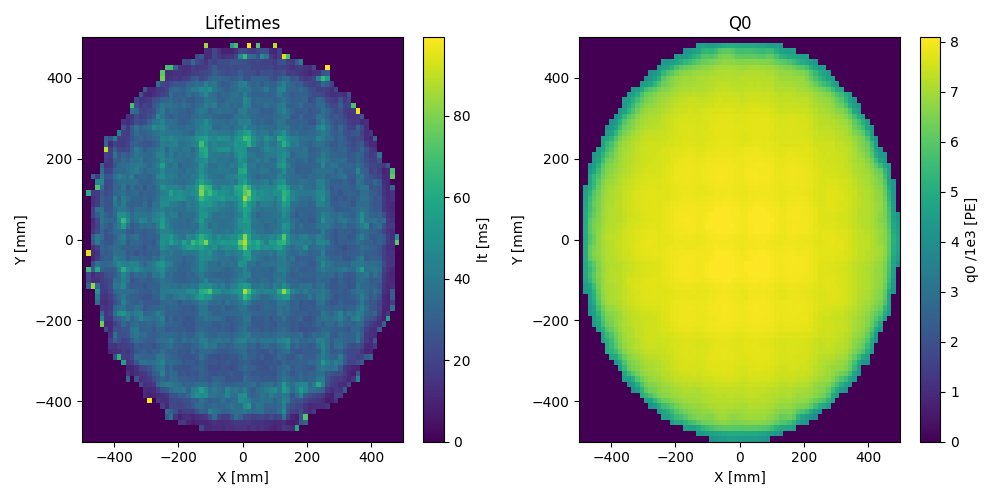

In [95]:
%matplotlib widget

display(lifetime_df)

# Function to extract x and y positions from bin_id
def get_bin_position_from_id(bin_id, x_bin_centers, y_bin_centers):
    try:
        x_bin, y_bin = map(int, bin_id.split('_'))  # Split and convert bin_id to integers
        return x_bin_centers[x_bin], y_bin_centers[y_bin]
    except (ValueError, IndexError) as e:
        return np.nan, np.nan  # Return NaN if there's an issue with the bin_id

# Apply the function to create new columns
lifetime_df_pos= lifetime_df
lifetime_df_pos[['x_center', 'y_center']] = lifetime_df['bin_id'].apply(
    lambda bid: pd.Series(get_bin_position_from_id(bid, x_bin_centers, y_bin_centers))
)


lifetime_df_pos.loc[lifetime_df_pos['lt'] > 100e3, 'lt'] = 0

# Create pivot table to reshape the data for 2D plotting
lt_pivot = lifetime_df_pos.pivot(index='y_center', columns='x_center', values='lt')

# Sort the axes (necessary if bin centers are not in order)
lt_pivot = lt_pivot.sort_index(ascending=False)  # y-axis usually goes from top to bottom
lt_pivot = lt_pivot.astype(float).fillna(0) 

# Create pivot table to reshape the data for 2D plotting
q0_pivot = lifetime_df_pos.pivot(index='y_center', columns='x_center', values='q0')

# Sort the axes (necessary if bin centers are not in order)
q0_pivot = q0_pivot.sort_index(ascending=False)  # y-axis usually goes from top to bottom
q0_pivot = q0_pivot.astype(float).fillna(0) 


# Plotting using matplotlib
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Create the pcolormesh plot
c = axs[0].pcolormesh(x_bins, y_bins, lt_pivot / 1e3, cmap='viridis', shading='auto')
fig.colorbar(c, ax=axs[0], label='lt [ms]')  # Specify 'ax' to link the color bar to the plot
axs[0].set_xlabel('X [mm]')
axs[0].set_ylabel('Y [mm]')
axs[0].set_title(f'Lifetimes')


c = axs[1].pcolormesh(x_bins, y_bins, q0_pivot / 1e3, cmap='viridis', shading='auto')
fig.colorbar(c, ax=axs[1], label='q0 /1e3 [PE]')  # Specify 'ax' to link the color bar to the plot
axs[1].set_xlabel('X [mm]')
axs[1].set_ylabel('Y [mm]')
axs[1].set_title(f'Q0')

plt.tight_layout()

In [3]:
lifetime_df["R"] = np.sqrt(lifetime_df["x_center"]**2 + lifetime_df["y_center"]**2)

(0.0, 500.0)

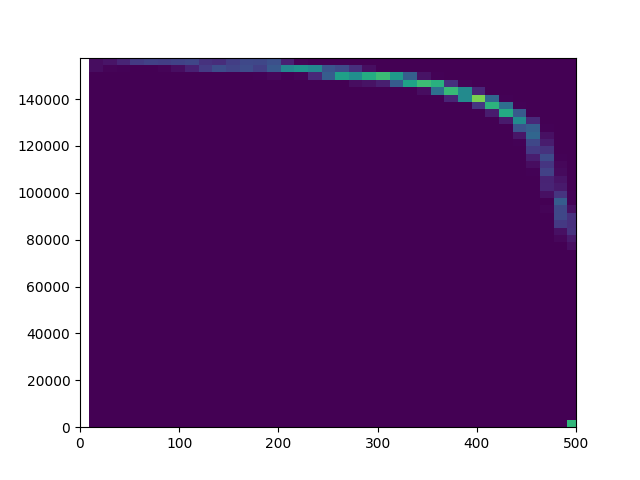

In [11]:
plt.figure()
plt.hist2d(lifetime_df["R"], 19.5*lifetime_df["q0"], bins = 50);
plt.xlim(0,500)

In [2]:
lifetime_df = pd.read_hdf(f"LifetimeMap_NEXT100MC.h5", key='map')

display(lifetime_df[(lifetime_df['lt'] > 80e3) & (lifetime_df['lt'] < 120e3)])

,bin_id,lt,q0,x_center,y_center
533,15_66,98332.822408,4635.766045,-290.540541,398.648649
825,11_62,115135.294985,4532.345465,-344.594595,344.594595
2035,37_46,87069.301594,7800.033657,6.756757,128.378378
2044,46_46,82855.087319,7729.498649,128.378378,128.378378
2074,2_45,84456.368931,4838.257852,-466.216216,114.864865
2517,1_39,93831.988858,5099.762735,-479.729730,33.783784
2701,37_37,87648.253197,7857.952852,6.756757,6.756757
2775,37_36,81491.454531,7883.105055,6.756757,-6.756757
3293,37_29,84340.004024,7849.863247,6.756757,-101.351351
3480,2_26,104034.707242,4755.640838,-466.216216,-141.891892


In [4]:
# lets see if we can explore the energy correction for the 600 keV tracks

def process_single_file_s(f):
    """Worker function for one file"""
    try:
        dst = pd.read_hdf(f, "RECO/Events")
        return dst
    except Exception as e:
        print(f"Error in {f}: {e}")
        return None

def LoadFilesParallel_s(filepath):
    files = glob.glob(filepath)
    
    # n_jobs=-1 uses all available cores (all 60)
    # prefer="threads" is good for I/O, but "processes" is better for pandas filtering
    results = Parallel(n_jobs=-1, verbose=10)( delayed(process_single_file_s)(f) for f in files)
    
    # Filter out None results if any files failed to load
    results = [res for res in results if res is not None]
    
    return pd.concat(results)


elec_samp = LoadFilesParallel_s(f"/media/argon/HardDrive_8TB/Krishan/Productions/NEXT100_single_eminus/sophronia/*.h5")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done  93 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 137 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 185 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 210 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 237 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 293 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 322 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 353 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 384 tasks      | elapsed:    4.2s
[Paralle

In [ ]:
elec_samp['x_bin'] = pd.cut(elec_samp['X'], bins=x_bins, labels=False)  # Labels as index (0, 1, 2,...)
elec_samp['y_bin'] = pd.cut(elec_samp['Y'], bins=y_bins, labels=False)

# Assign the bin centers as new columns
elec_samp['x_bin_center'] = elec_samp['x_bin'].map(lambda i: x_bin_centers[i] if pd.notna(i) else np.nan)
elec_samp['y_bin_center'] = elec_samp['y_bin'].map(lambda i: y_bin_centers[i] if pd.notna(i) else np.nan)

# Assign a unique bin ID for each (x_bin, y_bin) pair
elec_samp['bin_id'] = elec_samp['x_bin'].astype(str) + '_' + elec_samp['y_bin'].astype(str)

display(elec_samp)

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,...,E,Qc,Ec,track_id,Ep,x_bin,y_bin,x_bin_center,y_bin_center,bin_id
0,926800,1.853601e+12,0,35.158846,-443.300684,1,11.475,-483.425,0.0,0.0,...,710.206789,-1.0,0.004539,-1,-1.0,37,1,6.756757,-479.729730,37_1
1,926800,1.853601e+12,0,35.158846,-443.300684,1,27.025,-483.425,0.0,0.0,...,680.437651,-1.0,0.004334,-1,-1.0,38,1,20.270270,-479.729730,38_1
2,926800,1.853601e+12,0,35.158846,-443.300684,1,11.475,-483.425,0.0,0.0,...,857.284513,-1.0,0.005480,-1,-1.0,37,1,6.756757,-479.729730,37_1
3,926801,1.853603e+12,1,40.609936,-100.068622,1,42.575,-94.675,0.0,0.0,...,424.983621,-1.0,0.001671,-1,-1.0,40,29,47.297297,-101.351351,40_29
4,926801,1.853603e+12,1,40.609936,-100.068622,1,42.575,-79.125,0.0,0.0,...,725.243745,-1.0,0.002840,-1,-1.0,40,31,47.297297,-74.324324,40_31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39801,531399,1.062798e+12,0,-100.703319,436.605576,1,-128.475,434.025,0.0,0.0,...,249.310191,-1.0,0.001284,-1,-1.0,27,69,-128.378378,439.189189,27_69
39802,531399,1.062798e+12,0,-100.703319,436.605576,1,-128.475,449.575,0.0,0.0,...,604.577219,-1.0,0.003320,-1,-1.0,27,70,-128.378378,452.702703,27_70
39803,531399,1.062798e+12,0,-100.703319,436.605576,1,-128.475,465.125,0.0,0.0,...,305.404969,-1.0,0.002043,-1,-1.0,27,71,-128.378378,466.216216,27_71
39804,531399,1.062798e+12,0,-100.703319,436.605576,1,-112.925,434.025,0.0,0.0,...,442.525571,-1.0,0.002191,-1,-1.0,28,69,-114.864865,439.189189,28_69


: 

In [ ]:
# join the lt on so we can correct
merged_df = pd.merge(elec_samp, lifetime_df, on='bin_id', how='inner')
display(merged_df)

In [ ]:
safe_q0 = merged_df["q0"].replace(0, 1)

# 2. Perform division
merged_df["Ecorr"] = merged_df["E"] / safe_q0

In [ ]:
merged_df_avg = merged_df.groupby('event').agg({
    'X': 'mean',
    'Y': 'mean',
    'Z': 'median',
    "E" : "sum",
    'Ecorr' : 'sum',
    "Q" : 'sum'
}).reset_index()

merged_df_avg['radius'] = np.sqrt(merged_df_avg['X']**2 + merged_df_avg['Y']**2)

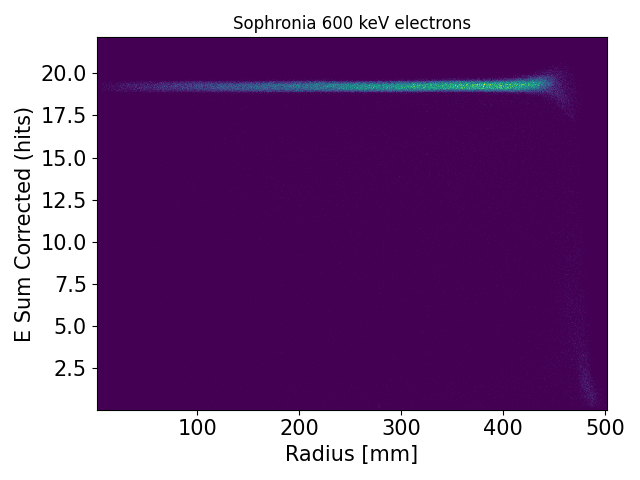

In [ ]:
plt.figure()
merged_df_avg = merged_df_avg[merged_df_avg.Ecorr < 25]
plt.hist2d(merged_df_avg.radius, merged_df_avg.Ecorr, bins= 500);
plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("E Sum Corrected (hits)", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()

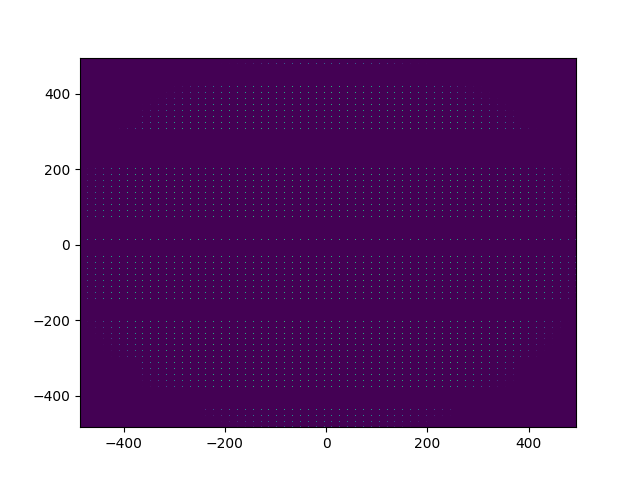

In [45]:
plt.figure()
# plt.hist(elec_samp.radius, bins = 100);
elec_samp['radius'] = np.sqrt(elec_samp['X']**2 + elec_samp['Y']**2)
plt.hist2d(elec_samp.X, elec_samp.Y, bins = 500);

In [33]:
sophronia_avg = elec_samp.groupby('event').agg({
    'X': 'mean',
    'Y': 'mean',
    'Z': 'median',
    'Ec': 'sum',
    'E' : 'sum',
    "Q" : 'sum'
}).reset_index()

# 2. Calculate the radial position (R) of the event center
# Using the averaged X and Y coordinates
sophronia_avg['radius'] = np.sqrt(sophronia_avg['X']**2 + sophronia_avg['Y']**2)

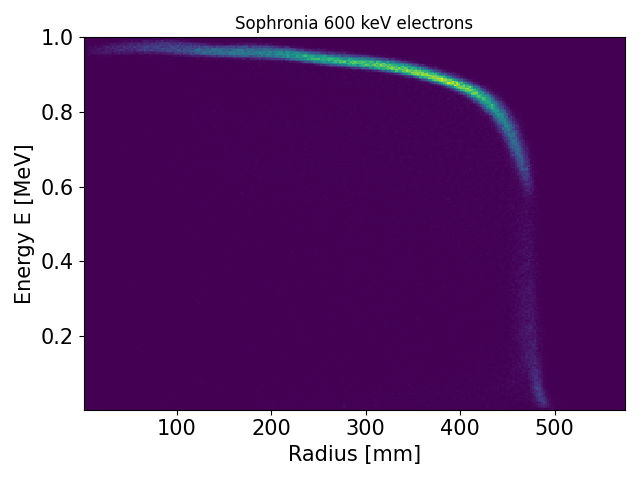

In [17]:
plt.figure()

plt.hist2d(sophronia_avg.radius, sophronia_avg.E/max(sophronia_avg.E), bins= 250);

plt.xlabel("Radius [mm]", fontsize = 15)
plt.ylabel("Energy E [MeV]", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Sophronia 600 keV electrons")
plt.tight_layout()


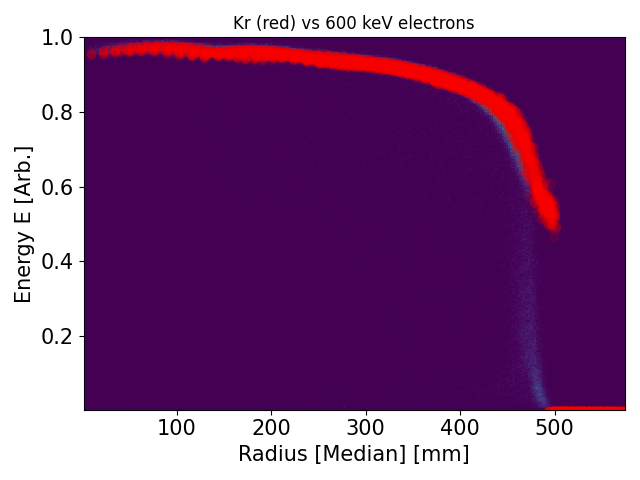

In [107]:
plt.figure()
plt.hist2d(sophronia_avg.radius, sophronia_avg.E/max(sophronia_avg.E), bins= 250);
plt.scatter(lifetime_df["R"], 0.98*lifetime_df["q0"]/max(lifetime_df["q0"]), alpha = 0.1, c = "red")


plt.xlabel("Radius [Median] [mm]", fontsize = 15)
plt.ylabel("Energy E [Arb.]", fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title("Kr (red) vs 600 keV electrons")
plt.tight_layout()
